In [1]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from catboost import CatBoostRegressor, Pool

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")



In [2]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path.cwd() / "notebook_exports"
ROUND_DATA_PATH = OUTPUT_DIR / "round_level_modeling_dataset_v1.parquet"

TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
RANDOM_STATE = 42

USE_LAYOUT_ID = False
USE_DIVISION = True
REQUIRE_WEATHER_AVAILABLE = True
MIN_HOLES_PLAYED = 18

MPH_TO_MPS = 0.44704
MPS_TO_MPH = 2.23694

TARGET_COL = "actual_round_strokes"

REFERENCE_WIND_MPH = 0.0
REFERENCE_WIND_GUST_MPH = 1.0
REFERENCE_TEMPERATURE_F = 80.0
REFERENCE_TEMPERATURE_C = (REFERENCE_TEMPERATURE_F - 32.0) * 5.0 / 9.0
REFERENCE_PRECIP_FLAG = 0

ONE_STAGE_CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 10000,
    "depth": 6,
    "learning_rate": 0.03,
    "l2_leaf_reg": 10.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}

EARLY_STOPPING_ROUNDS = 300

EXPERIMENT_NAME = "one_stage_catboost_monotone_wind"

print("Using local round dataset:", ROUND_DATA_PATH)
print("Reference wind (mph):", REFERENCE_WIND_MPH)
print("Reference gust (mph):", REFERENCE_WIND_GUST_MPH)
print("Reference temperature (F):", REFERENCE_TEMPERATURE_F)



Using local round dataset: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\round_level_modeling_dataset_v1.parquet
Reference wind (mph): 0.0
Reference gust (mph): 1.0
Reference temperature (F): 80.0


In [3]:
# -----------------------------------------------------------------------------
# Load data
# -----------------------------------------------------------------------------

round_level_df = pd.read_parquet(ROUND_DATA_PATH).copy()

print("Round-level shape:", round_level_df.shape)
round_level_df.head()


Round-level shape: (419842, 28)


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating
0,2025,90004,1,PDGA#240866,248066,731340,MA4,777.0,60.0,18,4262.0,236.777778,54.0,3.000000,2.99,2.99,5.3,5.3,15.6,0.0,0.0,1018.5,82.0,6.0,78.925926,12743.38,22588.6,2323.23
1,2025,90022,1,PDGA#139372,303386,708703,MPO,944.0,65.0,22,6640.0,301.818182,69.0,3.136364,0.69,0.69,3.0,3.0,3.7,0.0,0.0,1009.0,83.0,-4.0,96.231884,4581.60,19920.0,651.36
2,2025,90022,1,PDGA#178707,303386,708703,FPO,921.0,67.0,22,6640.0,301.818182,69.0,3.136364,1.38,1.38,2.7,2.7,1.1,0.0,0.0,1009.0,91.0,-2.0,96.231884,9163.20,17928.0,1270.98
3,2025,90022,1,PDGA#235527,303386,708703,MA2,861.0,72.0,22,6640.0,301.818182,69.0,3.136364,1.25,1.25,2.3,2.3,2.2,0.0,0.0,1009.7,89.0,3.0,96.231884,8300.00,15272.0,1076.25
4,2025,90022,2,PDGA#208891,303386,708709,MA50,887.0,79.0,22,7337.0,333.500000,70.0,3.181818,1.71,1.71,4.2,4.2,5.5,0.0,0.0,1004.7,77.0,9.0,104.814286,12546.27,30815.4,1516.77


In [4]:
# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def total_variation(values: pd.Series) -> float:
    diffs = np.diff(values.to_numpy(dtype=float))
    return float(np.abs(diffs).sum())


def second_difference_roughness(values: pd.Series) -> float:
    arr = values.to_numpy(dtype=float)
    if len(arr) < 3:
        return 0.0
    return float(np.abs(np.diff(arr, n=2)).sum())


def nonmonotone_steps(values: pd.Series, *, tolerance: float = 0.10) -> int:
    arr = values.to_numpy(dtype=float)
    if len(arr) < 2:
        return 0
    return int((np.diff(arr) < -tolerance).sum())


def analysis_wind_bucket_from_mph(speed_mph: float | None) -> str:
    if speed_mph is None or pd.isna(speed_mph):
        return "unknown"
    if speed_mph < 3:
        return "0-3"
    if speed_mph < 6:
        return "3-6"
    if speed_mph < 9:
        return "6-9"
    if speed_mph < 12:
        return "9-12"
    if speed_mph < 15:
        return "12-15"
    return "15+"


def analysis_temp_bucket_from_f(temp_f: float | None) -> str:
    if temp_f is None or pd.isna(temp_f):
        return "unknown"
    if temp_f < 30:
        return "<30"
    if temp_f < 40:
        return "30-40"
    if temp_f < 50:
        return "40-50"
    if temp_f < 60:
        return "50-60"
    if temp_f < 70:
        return "60-70"
    if temp_f < 80:
        return "70-80"
    return "80+"


OBSERVED_WIND_BUCKETS = ["0-3", "3-6", "6-9", "9-12", "12-15", "15+"]
OBSERVED_TEMP_BUCKETS = ["<30", "30-40", "40-50", "50-60", "60-70", "70-80", "80+"]


def prepare_one_stage_frame(
    df: pd.DataFrame,
    *,
    numeric_features: list[str],
    categorical_features: list[str],
    target_col: str,
    min_holes_played: int,
) -> pd.DataFrame:
    out = df.copy()

    if REQUIRE_WEATHER_AVAILABLE and "weather_available_flag" in out.columns:
        out = out[out["weather_available_flag"] == True].copy()  # noqa: E712

    if "hole_count" in out.columns:
        out["hole_count"] = pd.to_numeric(out["hole_count"], errors="coerce")
        out = out[out["hole_count"] >= min_holes_played].copy()

    required_cols = [target_col] + numeric_features + categorical_features
    missing = [c for c in required_cols if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for col in [target_col] + numeric_features:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=[target_col] + numeric_features).copy()

    for col in categorical_features:
        out[col] = out[col].astype("string").fillna("__MISSING__").astype(str)

    out["round_wind_speed_mph_mean"] = out["round_wind_speed_mps_mean"] * MPS_TO_MPH
    out["round_wind_gust_mph_mean"] = out["round_wind_gust_mps_mean"] * MPS_TO_MPH
    out["round_temp_f_mean"] = (out["round_temp_c_mean"] * 9.0 / 5.0) + 32.0

    out["precip_during_round_flag"] = (
        pd.to_numeric(out["round_precip_mm_sum"], errors="coerce")
        .fillna(0.0)
        .gt(0.0)
        .astype(int)
    )

    out["observed_wind_bucket"] = out["round_wind_speed_mph_mean"].map(analysis_wind_bucket_from_mph)
    out["observed_temp_bucket"] = out["round_temp_f_mean"].map(analysis_temp_bucket_from_f)

    return out


def build_catboost_pool(
    df: pd.DataFrame,
    *,
    feature_cols: list[str],
    categorical_features: list[str],
    target_col: str | None = None,
) -> Pool:
    cat_idx = [feature_cols.index(c) for c in categorical_features]

    if target_col is not None:
        return Pool(
            data=df[feature_cols],
            label=df[target_col],
            cat_features=cat_idx,
        )

    return Pool(
        data=df[feature_cols],
        cat_features=cat_idx,
    )


def build_counterfactual_df(
    base_df: pd.DataFrame,
    *,
    wind_speed_mph: float | None = None,
    wind_gust_mph: float | None = None,
    temperature_c: float | None = None,
    precip_flag: int | None = None,
) -> pd.DataFrame:
    out = base_df.copy()

    if wind_speed_mph is not None:
        out["round_wind_speed_mps_mean"] = wind_speed_mph * MPH_TO_MPS
        out["round_wind_speed_mph_mean"] = wind_speed_mph
        out["observed_wind_bucket"] = analysis_wind_bucket_from_mph(wind_speed_mph)

    if wind_gust_mph is not None:
        out["round_wind_gust_mps_mean"] = wind_gust_mph * MPH_TO_MPS
        out["round_wind_gust_mph_mean"] = wind_gust_mph

    if temperature_c is not None:
        out["round_temp_c_mean"] = float(temperature_c)
        out["round_temp_f_mean"] = (float(temperature_c) * 9.0 / 5.0) + 32.0
        out["observed_temp_bucket"] = analysis_temp_bucket_from_f(out["round_temp_f_mean"].iloc[0])

    if precip_flag is not None:
        out["precip_during_round_flag"] = int(precip_flag)

    return out


def build_effect_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric in [
        "estimated_wind_effect_vs_reference",
        "estimated_temperature_effect_vs_reference",
        "estimated_precip_effect_vs_reference",
        "estimated_total_weather_effect_vs_reference",
    ]:
        rows.append(
            {
                "metric": metric,
                "mean": float(df[metric].mean()),
                "median": float(df[metric].median()),
                "std": float(df[metric].std()),
                "p10": float(df[metric].quantile(0.10)),
                "p90": float(df[metric].quantile(0.90)),
            }
        )
    return pd.DataFrame(rows)



In [5]:
# -----------------------------------------------------------------------------
# Feature setup
# -----------------------------------------------------------------------------

model_df = round_level_df.copy()

NUMERIC_FEATURES = [
    "player_rating",
    "round_number",
    "hole_count",
    "round_total_hole_length",
    "round_avg_hole_length",
    "round_total_par",
    "round_avg_hole_par",
    "round_length_over_par",
    "round_wind_speed_mps_mean",
    "round_wind_gust_mps_mean",
    "round_temp_c_mean",
    "round_precip_mm_sum",
]

CATEGORICAL_FEATURES = [
    "course_id",
]

if USE_DIVISION:
    CATEGORICAL_FEATURES.append("division")

if USE_LAYOUT_ID:
    CATEGORICAL_FEATURES.append("layout_id")

FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)



Numeric features: ['player_rating', 'round_number', 'hole_count', 'round_total_hole_length', 'round_avg_hole_length', 'round_total_par', 'round_avg_hole_par', 'round_length_over_par', 'round_wind_speed_mps_mean', 'round_wind_gust_mps_mean', 'round_temp_c_mean', 'round_precip_mm_sum']
Categorical features: ['course_id', 'division']


In [6]:
# -----------------------------------------------------------------------------
# Train / validation / test split
# -----------------------------------------------------------------------------

train_full_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df, valid_df = train_test_split(
    train_full_df,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
)

train_prepped = prepare_one_stage_frame(
    train_df,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
    min_holes_played=MIN_HOLES_PLAYED,
)
valid_prepped = prepare_one_stage_frame(
    valid_df,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
    min_holes_played=MIN_HOLES_PLAYED,
)
test_prepped = prepare_one_stage_frame(
    test_df,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
    min_holes_played=MIN_HOLES_PLAYED,
)

print("Train rows:", len(train_prepped))
print("Valid rows:", len(valid_prepped))
print("Test rows:", len(test_prepped))



Train rows: 264129
Valid rows: 66031
Test rows: 82511


In [7]:
# -----------------------------------------------------------------------------
# Monotone constraints setup
# -----------------------------------------------------------------------------

feature_to_monotone = {feature: 0 for feature in FEATURE_COLS}
feature_to_monotone["round_wind_speed_mps_mean"] = 1
feature_to_monotone["round_wind_gust_mps_mean"] = 1

monotone_constraints = [feature_to_monotone[feature] for feature in FEATURE_COLS]

monotone_constraints_df = pd.DataFrame(
    {
        "feature": FEATURE_COLS,
        "monotone_constraint": monotone_constraints,
    }
)

display(monotone_constraints_df)

one_stage_catboost_params = ONE_STAGE_CATBOOST_PARAMS.copy()
one_stage_catboost_params["monotone_constraints"] = monotone_constraints


,feature,monotone_constraint
0,player_rating,0
1,round_number,0
2,hole_count,0
3,round_total_hole_length,0
4,round_avg_hole_length,0
5,round_total_par,0
6,round_avg_hole_par,0
7,round_length_over_par,0
8,round_wind_speed_mps_mean,1
9,round_wind_gust_mps_mean,1


In [8]:
# -----------------------------------------------------------------------------
# Train one-stage CatBoost model
# -----------------------------------------------------------------------------

train_pool = build_catboost_pool(
    train_prepped,
    feature_cols=FEATURE_COLS,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)
valid_pool = build_catboost_pool(
    valid_prepped,
    feature_cols=FEATURE_COLS,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)
test_pool = build_catboost_pool(
    test_prepped,
    feature_cols=FEATURE_COLS,
    categorical_features=CATEGORICAL_FEATURES,
    target_col=TARGET_COL,
)

one_stage_model = CatBoostRegressor(**one_stage_catboost_params)
one_stage_model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)

best_iteration = getattr(one_stage_model, "best_iteration_", None)

train_pred = one_stage_model.predict(train_pool)
valid_pred = one_stage_model.predict(valid_pool)
test_pred = one_stage_model.predict(test_pool)

metrics_df = pd.DataFrame(
    [
        {"split": "train", **regression_metrics(train_prepped[TARGET_COL], train_pred)},
        {"split": "valid", **regression_metrics(valid_prepped[TARGET_COL], valid_pred)},
        {"split": "test", **regression_metrics(test_prepped[TARGET_COL], test_pred)},
    ]
)
metrics_df["model"] = "one_stage_catboost_monotone"
metrics_df["best_iteration"] = best_iteration
metrics_df["feature_count"] = len(FEATURE_COLS)

metrics_df



0:	learn: 9.9201650	test: 9.8463447	best: 9.8463447 (0)	total: 264ms	remaining: 44m 4s
250:	learn: 4.6475711	test: 4.5593664	best: 4.5593664 (250)	total: 28.4s	remaining: 18m 21s
500:	learn: 4.4887931	test: 4.4007741	best: 4.4007741 (500)	total: 57.2s	remaining: 18m 3s
750:	learn: 4.4219629	test: 4.3361799	best: 4.3361799 (750)	total: 1m 29s	remaining: 18m 19s
1000:	learn: 4.3862304	test: 4.3033708	best: 4.3033708 (1000)	total: 2m 8s	remaining: 19m 18s
1250:	learn: 4.3620875	test: 4.2826242	best: 4.2826242 (1250)	total: 2m 41s	remaining: 18m 52s
1500:	learn: 4.3439142	test: 4.2678810	best: 4.2678590 (1499)	total: 3m 12s	remaining: 18m 10s
1750:	learn: 4.3296782	test: 4.2561479	best: 4.2561479 (1750)	total: 3m 45s	remaining: 17m 41s
2000:	learn: 4.3183802	test: 4.2468929	best: 4.2468905 (1996)	total: 4m 16s	remaining: 17m 6s
2250:	learn: 4.3087826	test: 4.2394373	best: 4.2394373 (2250)	total: 4m 51s	remaining: 16m 43s
2500:	learn: 4.3007883	test: 4.2332145	best: 4.2332128 (2499)	total: 

,split,mae,rmse,r2,model,best_iteration,feature_count
0,train,3.232413,4.293989,0.819199,one_stage_catboost_monotone,8553,14
1,valid,3.258409,4.272907,0.818287,one_stage_catboost_monotone,8553,14
2,test,3.289692,4.351485,0.813721,one_stage_catboost_monotone,8553,14


In [9]:
# -----------------------------------------------------------------------------
# Feature importance
# -----------------------------------------------------------------------------

feature_importance_df = one_stage_model.get_feature_importance(
    train_pool,
    prettified=True,
).rename(columns={"Feature Id": "feature", "Importances": "importance"})

feature_importance_df


,feature,importance
0,player_rating,22.176700
1,round_total_par,18.419773
2,round_length_over_par,15.419048
3,round_total_hole_length,13.400221
4,course_id,8.322877
5,round_avg_hole_par,5.840423
6,round_avg_hole_length,4.549593
7,round_temp_c_mean,4.047176
8,hole_count,1.981604
9,round_wind_speed_mps_mean,1.616955


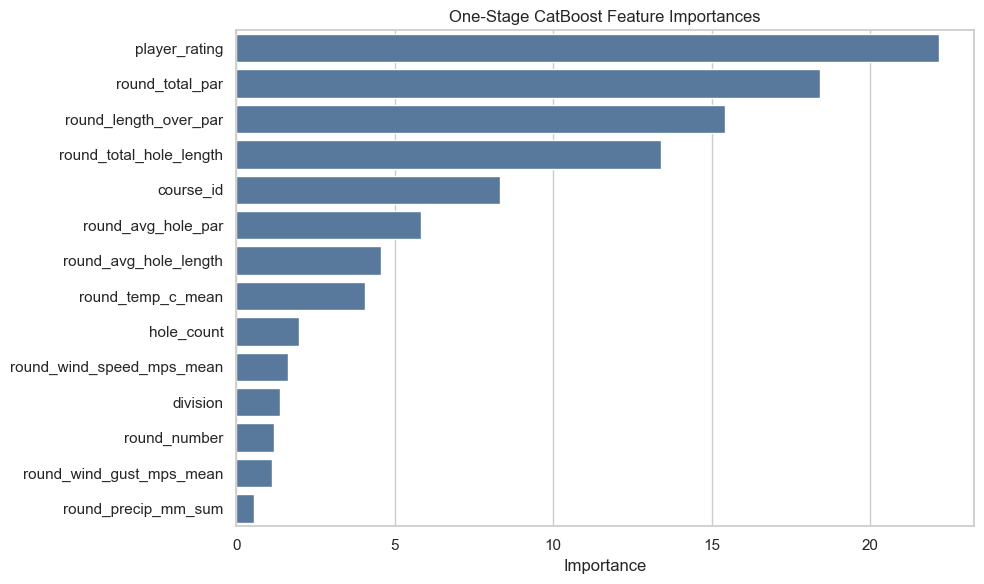

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(20),
    y="feature",
    x="importance",
    color="#4C78A8",
)
plt.title("One-Stage CatBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [11]:
# -----------------------------------------------------------------------------
# Score test rows under observed weather
# -----------------------------------------------------------------------------

scored_df = test_prepped.copy()
scored_df["predicted_round_strokes"] = test_pred
scored_df["round_residual_strokes"] = scored_df["actual_round_strokes"] - scored_df["predicted_round_strokes"]

scored_df.head()



,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,round_wind_speed_mph_mean,round_wind_gust_mph_mean,round_temp_f_mean,precip_during_round_flag,observed_wind_bucket,observed_temp_bucket,predicted_round_strokes,round_residual_strokes
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,9.283301,16.777050,59.72,0,9-12,50-60,77.709742,4.290258
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,6.487126,12.750558,65.12,0,6-9,60-70,102.596492,8.403508
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,6.352910,13.645334,78.98,1,6-9,70-80,42.832574,7.167426
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,8.030615,16.105968,30.02,0,6-9,30-40,57.342366,2.657634
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,3.288302,6.487126,60.44,0,3-6,60-70,67.136581,5.863419


In [12]:
# -----------------------------------------------------------------------------
# Weather counterfactual predictions on the test set
# -----------------------------------------------------------------------------

wind_reference_df = build_counterfactual_df(
    test_prepped,
    wind_speed_mph=REFERENCE_WIND_MPH,
    wind_gust_mph=REFERENCE_WIND_GUST_MPH,
)

temperature_reference_df = build_counterfactual_df(
    test_prepped,
    temperature_c=REFERENCE_TEMPERATURE_C,
)

precip_reference_df = build_counterfactual_df(
    test_prepped,
    precip_flag=REFERENCE_PRECIP_FLAG,
)

total_weather_reference_df = build_counterfactual_df(
    test_prepped,
    wind_speed_mph=REFERENCE_WIND_MPH,
    wind_gust_mph=REFERENCE_WIND_GUST_MPH,
    temperature_c=REFERENCE_TEMPERATURE_C,
    precip_flag=REFERENCE_PRECIP_FLAG,
)

wind_reference_pred = one_stage_model.predict(
    build_catboost_pool(
        wind_reference_df,
        feature_cols=FEATURE_COLS,
        categorical_features=CATEGORICAL_FEATURES,
    )
)
temperature_reference_pred = one_stage_model.predict(
    build_catboost_pool(
        temperature_reference_df,
        feature_cols=FEATURE_COLS,
        categorical_features=CATEGORICAL_FEATURES,
    )
)
precip_reference_pred = one_stage_model.predict(
    build_catboost_pool(
        precip_reference_df,
        feature_cols=FEATURE_COLS,
        categorical_features=CATEGORICAL_FEATURES,
    )
)
total_weather_reference_pred = one_stage_model.predict(
    build_catboost_pool(
        total_weather_reference_df,
        feature_cols=FEATURE_COLS,
        categorical_features=CATEGORICAL_FEATURES,
    )
)

scored_df["estimated_wind_effect_vs_reference"] = scored_df["predicted_round_strokes"] - wind_reference_pred
scored_df["estimated_temperature_effect_vs_reference"] = scored_df["predicted_round_strokes"] - temperature_reference_pred
scored_df["estimated_precip_effect_vs_reference"] = scored_df["predicted_round_strokes"] - precip_reference_pred
scored_df["estimated_total_weather_effect_vs_reference"] = scored_df["predicted_round_strokes"] - total_weather_reference_pred

scored_df.head()



,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,round_wind_speed_mph_mean,round_wind_gust_mph_mean,round_temp_f_mean,precip_during_round_flag,observed_wind_bucket,observed_temp_bucket,predicted_round_strokes,round_residual_strokes,estimated_wind_effect_vs_reference,estimated_temperature_effect_vs_reference,estimated_precip_effect_vs_reference,estimated_total_weather_effect_vs_reference
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,9.283301,16.777050,59.72,0,9-12,50-60,77.709742,4.290258,2.046327,0.274512,0.0,2.200176
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,6.487126,12.750558,65.12,0,6-9,60-70,102.596492,8.403508,1.446023,0.899188,0.0,2.382329
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,6.352910,13.645334,78.98,1,6-9,70-80,42.832574,7.167426,0.499974,0.008992,0.0,0.509721
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,8.030615,16.105968,30.02,0,6-9,30-40,57.342366,2.657634,0.865289,0.916409,0.0,1.483737
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,3.288302,6.487126,60.44,0,3-6,60-70,67.136581,5.863419,1.044536,0.153537,0.0,1.216323


In [13]:
weather_effect_summary_df = build_effect_summary(scored_df)
weather_effect_summary_df


,metric,mean,median,std,p10,p90
0,estimated_wind_effect_vs_reference,0.925520,0.728604,0.691914,0.303119,1.750126
1,estimated_temperature_effect_vs_reference,0.326052,0.243511,0.533430,-0.108318,0.859457
2,estimated_precip_effect_vs_reference,0.000000,0.000000,0.000000,0.000000,0.000000
3,estimated_total_weather_effect_vs_reference,1.221733,1.035879,0.845833,0.480729,2.163468


In [14]:
# -----------------------------------------------------------------------------
# Grouped summaries
# -----------------------------------------------------------------------------

wind_bucket_summary = (
    scored_df.groupby("observed_wind_bucket", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        wind_speed_mph_mean=("round_wind_speed_mph_mean", "mean"),
        estimated_wind_effect_mean=("estimated_wind_effect_vs_reference", "mean"),
        estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_reference", "mean"),
    )
    .reset_index()
)

temperature_band_summary = (
    scored_df.groupby("observed_temp_bucket", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        temp_f_mean=("round_temp_f_mean", "mean"),
        estimated_temperature_effect_mean=("estimated_temperature_effect_vs_reference", "mean"),
        estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_reference", "mean"),
    )
    .reset_index()
)

precip_summary = (
    scored_df.groupby("precip_during_round_flag", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        estimated_precip_effect_mean=("estimated_precip_effect_vs_reference", "mean"),
        estimated_total_weather_effect_mean=("estimated_total_weather_effect_vs_reference", "mean"),
    )
    .reset_index()
)

print("Wind bucket summary")
display(wind_bucket_summary)

print("Temperature-band summary")
display(temperature_band_summary)

print("Precipitation summary")
display(precip_summary)


Wind bucket summary


,observed_wind_bucket,rows,wind_speed_mph_mean,estimated_wind_effect_mean,estimated_total_weather_effect_mean
0,0-3,17614,1.807141,0.476577,0.797329
1,12-15,4072,13.217113,2.110538,2.436762
2,15+,2096,17.170115,2.735685,3.115810
3,3-6,28464,4.503577,0.628474,0.918838
4,6-9,20271,7.372077,1.041649,1.322448
5,9-12,9994,10.277698,1.464769,1.735830


Temperature-band summary


,observed_temp_bucket,rows,temp_f_mean,estimated_temperature_effect_mean,estimated_total_weather_effect_mean
0,30-40,6171,35.710637,0.655305,1.502023
1,40-50,11845,45.506519,0.560492,1.488466
2,50-60,19201,55.490445,0.412235,1.378421
3,60-70,21923,64.835225,0.222068,1.115556
4,70-80,15727,74.597577,0.113118,0.939985
5,80+,5331,85.330107,-0.236609,0.620113
6,<30,2313,22.724747,1.261815,2.115949


Precipitation summary


,precip_during_round_flag,rows,estimated_precip_effect_mean,estimated_total_weather_effect_mean
0,0,72504,0.0,1.179108
1,1,10007,0.0,1.530562


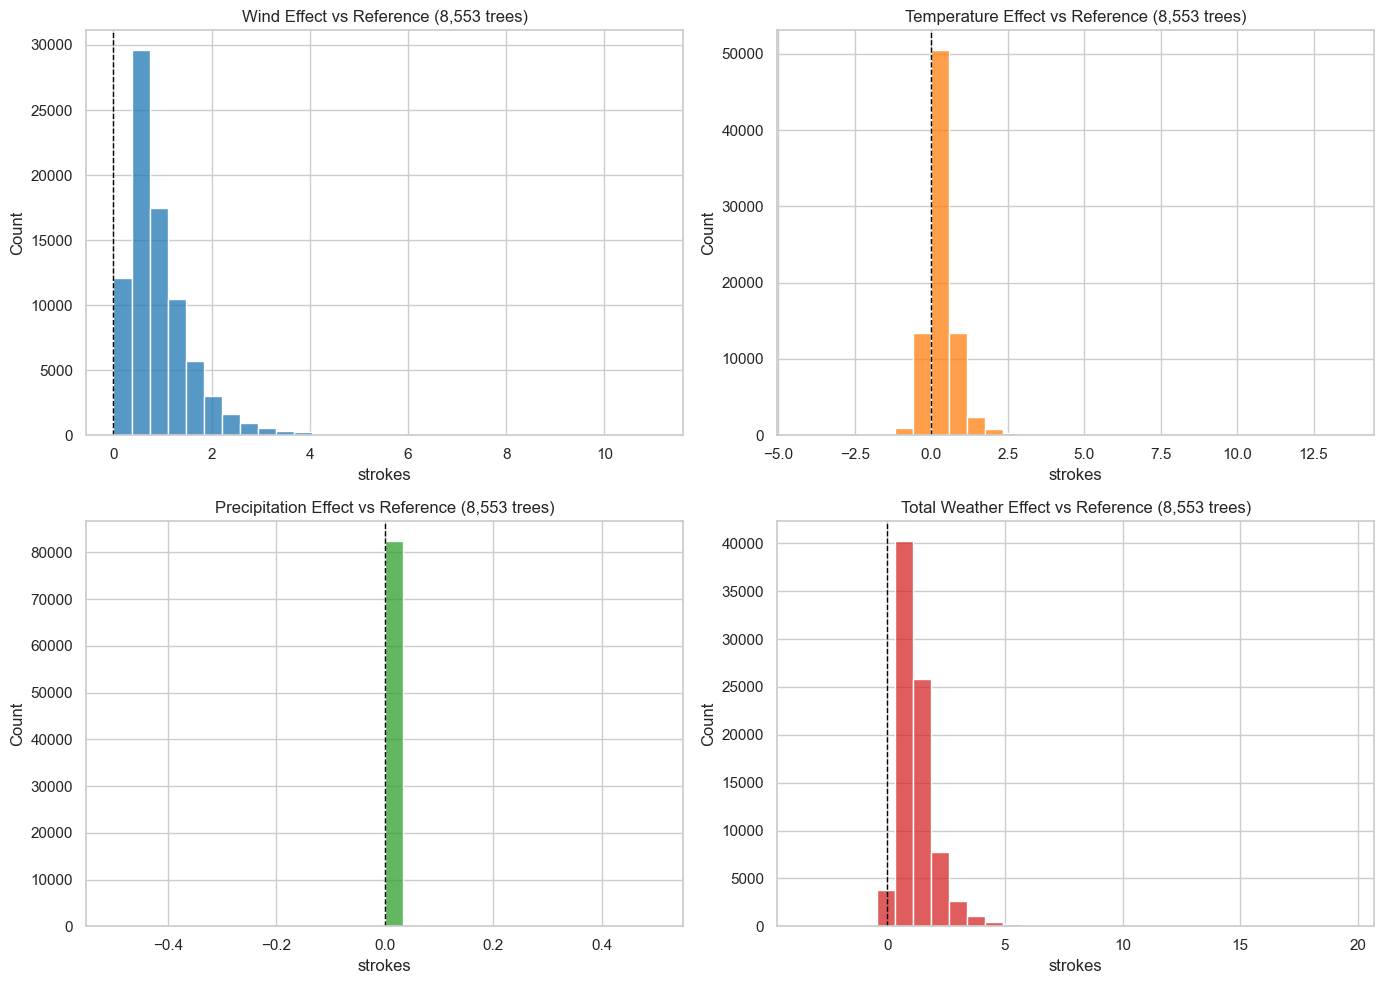

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(scored_df["estimated_wind_effect_vs_reference"], bins=30, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title(f"Wind Effect vs Reference ({best_iteration:,} trees)" if best_iteration is not None else "Wind Effect vs Reference")
axes[0, 0].set_xlabel("strokes")
axes[0, 0].set_ylabel("Count")

sns.histplot(scored_df["estimated_temperature_effect_vs_reference"], bins=30, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title(f"Temperature Effect vs Reference ({best_iteration:,} trees)" if best_iteration is not None else "Temperature Effect vs Reference")
axes[0, 1].set_xlabel("strokes")
axes[0, 1].set_ylabel("Count")

sns.histplot(scored_df["estimated_precip_effect_vs_reference"], bins=30, ax=axes[1, 0], color="#2ca02c")
axes[1, 0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 0].set_title(f"Precipitation Effect vs Reference ({best_iteration:,} trees)" if best_iteration is not None else "Precipitation Effect vs Reference")
axes[1, 0].set_xlabel("strokes")
axes[1, 0].set_ylabel("Count")

sns.histplot(scored_df["estimated_total_weather_effect_vs_reference"], bins=30, ax=axes[1, 1], color="#d62728")
axes[1, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title(f"Total Weather Effect vs Reference ({best_iteration:,} trees)" if best_iteration is not None else "Total Weather Effect vs Reference")
axes[1, 1].set_xlabel("strokes")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [16]:
# -----------------------------------------------------------------------------
# Wind-bucket box plot
# -----------------------------------------------------------------------------

wind_effect_boxplot_df = scored_df.copy()
wind_effect_boxplot_df["observed_wind_bucket_str"] = (
    wind_effect_boxplot_df["observed_wind_bucket"].astype(str).str.strip()
)

wind_effect_boxplot_df["observed_wind_bucket_plot"] = pd.Categorical(
    wind_effect_boxplot_df["observed_wind_bucket_str"],
    categories=OBSERVED_WIND_BUCKETS,
    ordered=True,
)

wind_effect_bucket_summary_df = (
    wind_effect_boxplot_df.groupby("observed_wind_bucket_str", dropna=False)
    .agg(
        rows=("player_rating", "size"),
        avg_observed_wind_mph=("round_wind_speed_mph_mean", "mean"),
        mean_effect=("estimated_wind_effect_vs_reference", "mean"),
        median_effect=("estimated_wind_effect_vs_reference", "median"),
        p10_effect=("estimated_wind_effect_vs_reference", lambda s: s.quantile(0.10)),
        p25_effect=("estimated_wind_effect_vs_reference", lambda s: s.quantile(0.25)),
        p75_effect=("estimated_wind_effect_vs_reference", lambda s: s.quantile(0.75)),
        p90_effect=("estimated_wind_effect_vs_reference", lambda s: s.quantile(0.90)),
    )
    .reset_index()
)

wind_effect_bucket_summary_df["bucket_order"] = wind_effect_bucket_summary_df[
    "observed_wind_bucket_str"
].map({bucket: idx for idx, bucket in enumerate(OBSERVED_WIND_BUCKETS)})

wind_effect_bucket_summary_df = (
    wind_effect_bucket_summary_df.sort_values("bucket_order")
    .drop(columns="bucket_order")
    .reset_index(drop=True)
)

wind_effect_bucket_summary_df


,observed_wind_bucket_str,rows,avg_observed_wind_mph,mean_effect,median_effect,p10_effect,p25_effect,p75_effect,p90_effect
0,0-3,17614,1.807141,0.476577,0.462267,0.202520,0.297743,0.608557,0.761910
1,3-6,28464,4.503577,0.628474,0.573144,0.274852,0.405973,0.795217,1.064357
2,6-9,20271,7.372077,1.041649,0.969155,0.525693,0.699780,1.282261,1.605295
3,9-12,9994,10.277698,1.464769,1.373919,0.801117,1.023265,1.711423,2.144175
4,12-15,4072,13.217113,2.110538,1.957285,1.328316,1.634788,2.365423,2.881257
5,15+,2096,17.170115,2.735685,2.593633,1.618215,2.006608,3.210017,3.952098


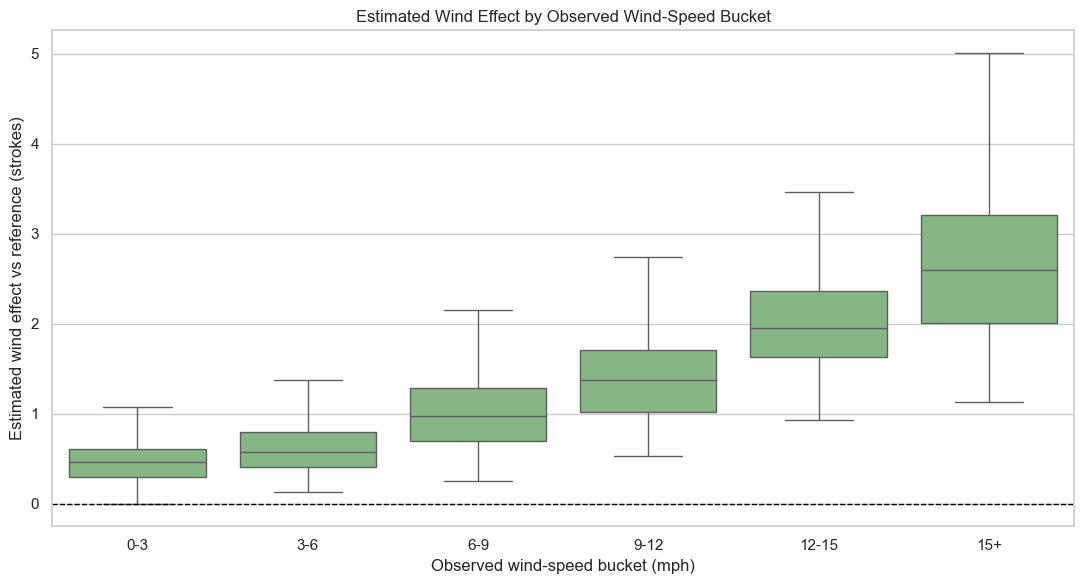

In [17]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=wind_effect_boxplot_df,
    x="observed_wind_bucket_plot",
    y="estimated_wind_effect_vs_reference",
    showfliers=False,
    color="#7DBE7A",
)

plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Estimated Wind Effect by Observed Wind-Speed Bucket")
plt.xlabel("Observed wind-speed bucket (mph)")
plt.ylabel("Estimated wind effect vs reference (strokes)")
plt.tight_layout()
plt.show()


In [18]:
# -----------------------------------------------------------------------------
# Partial dependence style counterfactual curves
# -----------------------------------------------------------------------------

pdp_base_df = test_prepped.copy()

wind_grid_mph = [0, 2, 5, 8, 12, 16, 20]
temperature_grid_c = [0, 5, 10, 12, 15, 18, 21, 24, 27, 30]

wind_curve_rows = []

REFERENCE_GUST_GAP_MPH = max(0.0, REFERENCE_WIND_GUST_MPH - REFERENCE_WIND_MPH)

for wind_mph in wind_grid_mph:
    linked_gust_mph = max(wind_mph, wind_mph + REFERENCE_GUST_GAP_MPH)

    actual_df = build_counterfactual_df(
        pdp_base_df,
        wind_speed_mph=wind_mph,
        wind_gust_mph=linked_gust_mph,
    )
    reference_df = build_counterfactual_df(
        pdp_base_df,
        wind_speed_mph=REFERENCE_WIND_MPH,
        wind_gust_mph=REFERENCE_WIND_GUST_MPH,
    )

    actual_pred = one_stage_model.predict(
        build_catboost_pool(actual_df, feature_cols=FEATURE_COLS, categorical_features=CATEGORICAL_FEATURES)
    )
    reference_pred = one_stage_model.predict(
        build_catboost_pool(reference_df, feature_cols=FEATURE_COLS, categorical_features=CATEGORICAL_FEATURES)
    )

    effect_values = actual_pred - reference_pred

    wind_curve_rows.append(
        {
            "wind_speed_mph": wind_mph,
            "effect_mean": float(np.mean(effect_values)),
            "effect_median": float(np.median(effect_values)),
            "effect_std": float(np.std(effect_values)),
            "effect_p10": float(np.quantile(effect_values, 0.10)),
            "effect_p90": float(np.quantile(effect_values, 0.90)),
        }
    )

wind_effect_pdp_df = pd.DataFrame(wind_curve_rows)
wind_effect_pdp_df


,wind_speed_mph,effect_mean,effect_median,effect_std,effect_p10,effect_p90
0,0,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,0.453155,0.459661,0.199457,0.192002,0.678813
2,5,0.592640,0.586249,0.243053,0.279643,0.894090
3,8,0.939513,0.861240,0.426567,0.484162,1.463059
4,12,1.529343,1.463533,0.568814,0.910713,2.180719
5,16,2.000314,1.915290,0.694098,1.255921,2.778086
6,20,2.228001,2.140097,0.722630,1.456090,3.029578


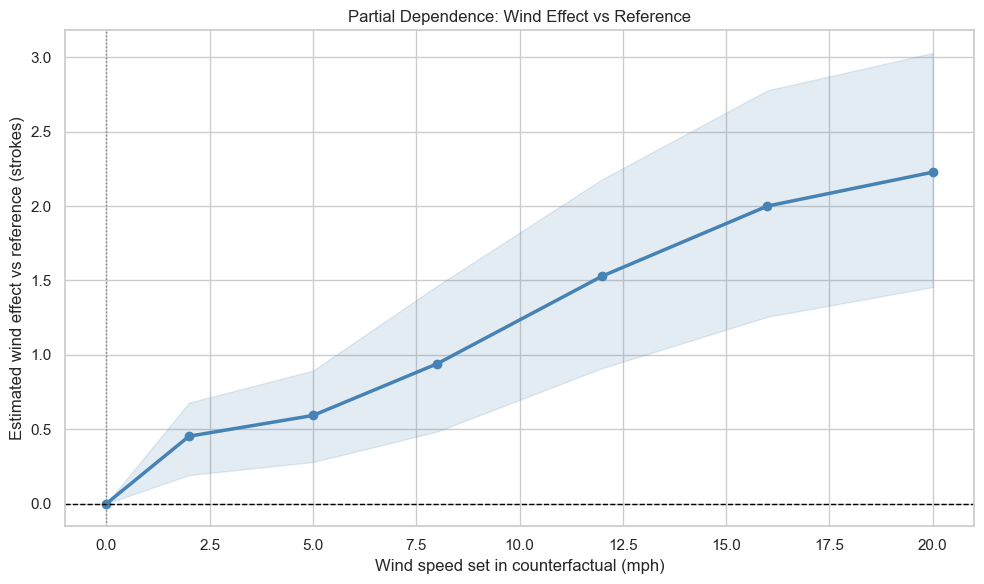

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(
    wind_effect_pdp_df["wind_speed_mph"],
    wind_effect_pdp_df["effect_mean"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
)
plt.fill_between(
    wind_effect_pdp_df["wind_speed_mph"],
    wind_effect_pdp_df["effect_p10"],
    wind_effect_pdp_df["effect_p90"],
    color="steelblue",
    alpha=0.15,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.axvline(REFERENCE_WIND_MPH, color="gray", linestyle=":", linewidth=1)
plt.title("Partial Dependence: Wind Effect vs Reference")
plt.xlabel("Wind speed set in counterfactual (mph)")
plt.ylabel("Estimated wind effect vs reference (strokes)")
plt.tight_layout()
plt.show()


In [20]:
temperature_curve_rows = []

for temp_c in temperature_grid_c:
    actual_df = build_counterfactual_df(
        pdp_base_df,
        temperature_c=temp_c,
    )
    reference_df = build_counterfactual_df(
        pdp_base_df,
        temperature_c=REFERENCE_TEMPERATURE_C,
    )

    actual_pred = one_stage_model.predict(
        build_catboost_pool(actual_df, feature_cols=FEATURE_COLS, categorical_features=CATEGORICAL_FEATURES)
    )
    reference_pred = one_stage_model.predict(
        build_catboost_pool(reference_df, feature_cols=FEATURE_COLS, categorical_features=CATEGORICAL_FEATURES)
    )

    effect_values = actual_pred - reference_pred

    temperature_curve_rows.append(
        {
            "temperature_c": temp_c,
            "temperature_f": (temp_c * 9.0 / 5.0) + 32.0,
            "effect_mean": float(np.mean(effect_values)),
            "effect_median": float(np.median(effect_values)),
            "effect_std": float(np.std(effect_values)),
            "effect_p10": float(np.quantile(effect_values, 0.10)),
            "effect_p90": float(np.quantile(effect_values, 0.90)),
        }
    )

temperature_effect_pdp_df = pd.DataFrame(temperature_curve_rows)
temperature_effect_pdp_df


,temperature_c,temperature_f,effect_mean,effect_median,effect_std,effect_p10,effect_p90
0,0,32.0,0.780663,0.759433,0.663703,0.068586,1.459057
1,5,41.0,0.585564,0.608791,0.542288,-0.013641,1.076738
2,10,50.0,0.560595,0.574349,0.516939,0.012653,0.986985
3,12,53.6,0.484120,0.495377,0.469487,-0.004336,0.847146
4,15,59.0,0.321558,0.301722,0.372672,-0.028406,0.595540
5,18,64.4,0.240827,0.239656,0.277583,-0.048711,0.479268
6,21,69.8,0.151668,0.155520,0.238986,-0.114626,0.381792
7,24,75.2,0.116326,0.094562,0.162896,-0.049851,0.298639
8,27,80.6,-0.006485,-0.006249,0.006378,-0.013742,-0.002818
9,30,86.0,-0.372516,-0.390328,0.209835,-0.591903,-0.107243


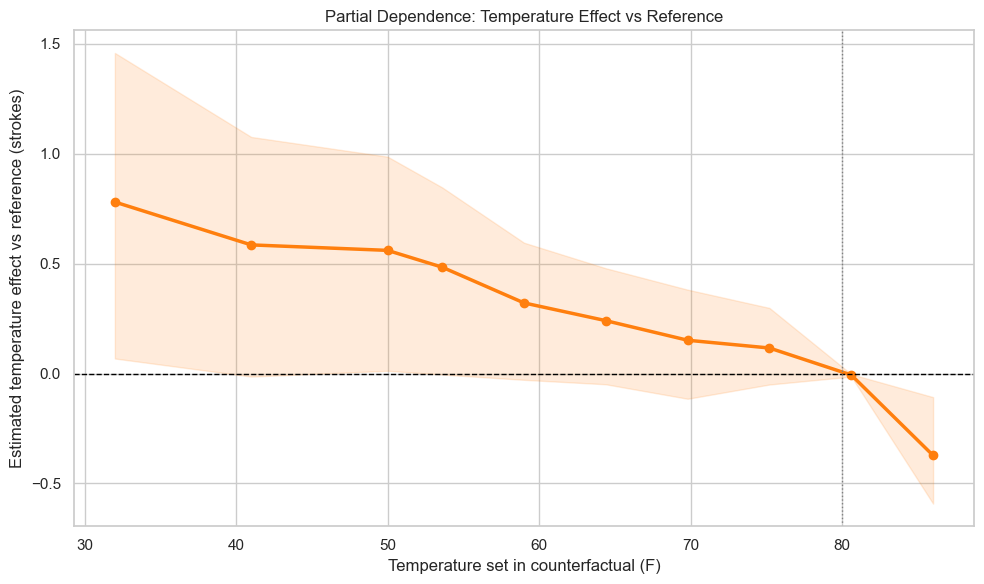

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(
    temperature_effect_pdp_df["temperature_f"],
    temperature_effect_pdp_df["effect_mean"],
    marker="o",
    linewidth=2.5,
    color="#ff7f0e",
)
plt.fill_between(
    temperature_effect_pdp_df["temperature_f"],
    temperature_effect_pdp_df["effect_p10"],
    temperature_effect_pdp_df["effect_p90"],
    color="#ff7f0e",
    alpha=0.15,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.axvline(REFERENCE_TEMPERATURE_F, color="gray", linestyle=":", linewidth=1)
plt.title("Partial Dependence: Temperature Effect vs Reference")
plt.xlabel("Temperature set in counterfactual (F)")
plt.ylabel("Estimated temperature effect vs reference (strokes)")
plt.tight_layout()
plt.show()
